# All-to-All MFPT: Simulation vs Julia Theory

This notebook compares mean first-passage times (MFPT) to consensus using:
- Monte Carlo simulation from the Julia API
- Analytical Julia formulas (ported from `voter_model` and exposed in `VoterResetting`)

The sweep spans ranges of `N`, `m0`, and `r`.

In [17]:
using Random
using Statistics
using Printf
using Plots

candidates = [abspath(pwd()), abspath(joinpath(pwd(), "..")), abspath(joinpath(pwd(), "..", ".."))]
project_root = nothing
for p in candidates
    if isfile(joinpath(p, "src", "VoterResetting.jl"))
        global project_root = p
        break
    end
end
project_root === nothing && error("Could not locate project root containing src/VoterResetting.jl from pwd=$(pwd())")

include(joinpath(project_root, "src", "VoterResetting.jl"))
const VR = VoterResetting

Main.VoterResetting

In [8]:
function mfpt_sweep_all_to_all(
    N_values, m0_values, r_values;
    nsamples=400,
    M=600,
    seed=1234,
    use_python_rate_scaling=true,
    first_point_refine_nsamples=5000,
    first_point_refine_M=2000,
    verbose=true,
)
    Random.seed!(seed)
    rows = NamedTuple[]

    total = length(N_values) * length(m0_values) * length(r_values)
    done = 0

    for N in N_values
        for m0 in m0_values
            for r in r_values
                # Theory in this notebook follows the Python convention: mean_fpt scales r internally as r/N.
                # To compare apples-to-apples, use r_sim = r/N in Gillespie when this flag is true.
                r_sim = use_python_rate_scaling ? (r / N) : r

                params = VR.AllToAllParams(N, r_sim, m0)
                sim = VR.first_passage_time_all_to_all(
                    params;
                    consensus_type=:either,
                    nsamples=nsamples,
                    reset=VR.delta_reset(m0),
                )

                th = VR.mean_fpt(N, m0, r; M=M)
                sim_stderr = sim.std_fpt / sqrt(nsamples)
                rel_err = (sim.mean_fpt - th) / th
                zscore = (sim.mean_fpt - th) / max(sim_stderr, 1e-12)

                # Optional expensive check for the first sweep point (often the noisiest/slowest).
                if done == 0 && first_point_refine_nsamples > nsamples
                    sim_ref = VR.first_passage_time_all_to_all(
                        params;
                        consensus_type=:either,
                        nsamples=first_point_refine_nsamples,
                        reset=VR.delta_reset(m0),
                    )
                    th_ref = VR.mean_fpt(N, m0, r; M=first_point_refine_M)
                    sim_stderr_ref = sim_ref.std_fpt / sqrt(first_point_refine_nsamples)
                    rel_err_ref = (sim_ref.mean_fpt - th_ref) / th_ref
                    zscore_ref = (sim_ref.mean_fpt - th_ref) / max(sim_stderr_ref, 1e-12)

                    push!(rows, (
                        N=N,
                        m0=m0,
                        r=r,
                        r_sim=r_sim,
                        nsamples=first_point_refine_nsamples,
                        M=first_point_refine_M,
                        mfpt_sim=sim_ref.mean_fpt,
                        mfpt_theory=th_ref,
                        std_sim=sim_ref.std_fpt,
                        stderr_sim=sim_stderr_ref,
                        rel_err=rel_err_ref,
                        zscore=zscore_ref,
                        refined=true,
                    ))

                    done += 1
                    if verbose
                        @printf("[%d/%d][refined] N=%d, m0=%.3f, r=%.3f, r_sim=%.6g -> sim=%.5g ± %.3g, theory=%.5g, rel_err=%.3e, z=%.2f\n",
                            done, total, N, m0, r, r_sim, sim_ref.mean_fpt, sim_stderr_ref, th_ref, rel_err_ref, zscore_ref)
                    end
                    continue
                end

                push!(rows, (
                    N=N,
                    m0=m0,
                    r=r,
                    r_sim=r_sim,
                    nsamples=nsamples,
                    M=M,
                    mfpt_sim=sim.mean_fpt,
                    mfpt_theory=th,
                    std_sim=sim.std_fpt,
                    stderr_sim=sim_stderr,
                    rel_err=rel_err,
                    zscore=zscore,
                    refined=false,
                ))

                done += 1
                if verbose
                    @printf("[%d/%d] N=%d, m0=%.3f, r=%.3f, r_sim=%.6g -> sim=%.5g ± %.3g, theory=%.5g, rel_err=%.3e, z=%.2f\n",
                        done, total, N, m0, r, r_sim, sim.mean_fpt, sim_stderr, th, rel_err, zscore)
                end
            end
        end
    end

    return rows
end

mfpt_sweep_all_to_all (generic function with 1 method)

In [9]:
N_values = [200, 500, 1000]
m0_values = [-0.5, 0.0, 0.5, 0.9]
r_values = [0.1, 0.3, 0.7, 1.5, 3.0, 7.0, 15.0, 30.0]

# Fast baseline sweep + expensive first-point refinement for diagnostics.
nsamples = 400
M = 600

rows = mfpt_sweep_all_to_all(
    N_values, m0_values, r_values;
    nsamples=nsamples,
    M=M,
    seed=42,
    use_python_rate_scaling=true,
    first_point_refine_nsamples=5000,
    first_point_refine_M=2000,
    verbose=true,
)
println("Computed $(length(rows)) parameter points.")

[1/96][refined] N=200, m0=-0.500, r=0.100, r_sim=0.0005 -> sim=112.01 ± 1.42, theory=112.02, rel_err=-1.347e-04, z=-0.01
[2/96] N=200, m0=-0.500, r=0.300, r_sim=0.0015 -> sim=118.31 ± 5.05, theory=117.86, rel_err=3.787e-03, z=0.09
[3/96] N=200, m0=-0.500, r=0.700, r_sim=0.0035 -> sim=115.29 ± 4.92, theory=121.53, rel_err=-5.134e-02, z=-1.27
[4/96] N=200, m0=-0.500, r=1.500, r_sim=0.0075 -> sim=129.77 ± 5.99, theory=129.43, rel_err=2.648e-03, z=0.06
[5/96] N=200, m0=-0.500, r=3.000, r_sim=0.015 -> sim=121.74 ± 5.57, theory=146.48, rel_err=-1.689e-01, z=-4.45
[6/96] N=200, m0=-0.500, r=7.000, r_sim=0.035 -> sim=170.48 ± 7.89, theory=212.06, rel_err=-1.961e-01, z=-5.27
[7/96] N=200, m0=-0.500, r=15.000, r_sim=0.075 -> sim=275.15 ± 13.2, theory=643.66, rel_err=-5.725e-01, z=-28.00
[8/96] N=200, m0=-0.500, r=30.000, r_sim=0.15 -> sim=609.33 ± 29, theory=-454.35, rel_err=-2.341e+00, z=36.72
[9/96] N=200, m0=0.000, r=0.100, r_sim=0.0005 -> sim=133.58 ± 4.79, theory=144.42, rel_err=-7.508e-02,

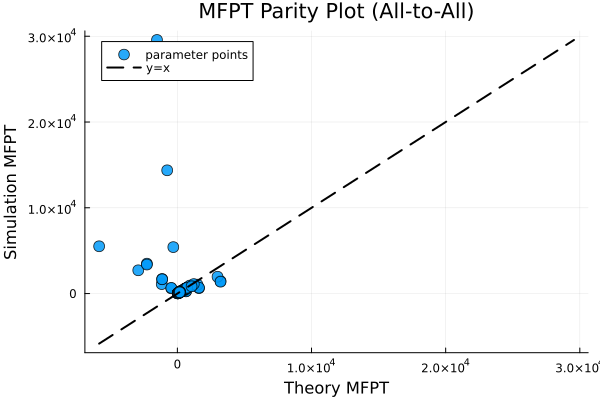

In [10]:
theory = [x.mfpt_theory for x in rows]
sim = [x.mfpt_sim for x in rows]
labels = ["N=$(x.N), m0=$(x.m0), r=$(x.r)" for x in rows]

lo = min(minimum(theory), minimum(sim))
hi = max(maximum(theory), maximum(sim))

p_parity = scatter(
    theory, sim;
    xlabel="Theory MFPT",
    ylabel="Simulation MFPT",
    title="MFPT Parity Plot (All-to-All)",
    markersize=6,
    alpha=0.85,
    label="parameter points",
    legend=:topleft,
)
plot!(p_parity, [lo, hi], [lo, hi]; lw=2, ls=:dash, color=:black, label="y=x")
display(p_parity)

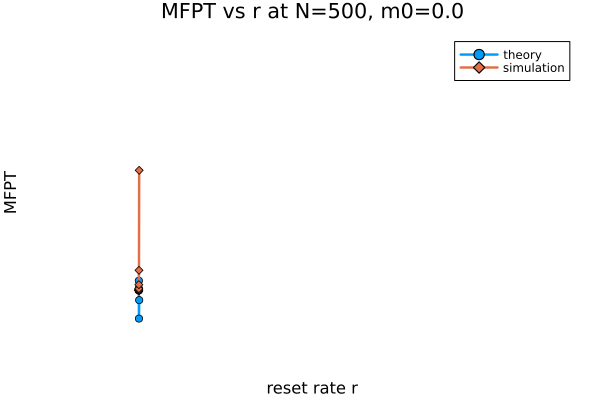

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value -2916.2192021893457 found at series index 7 for log10 based yscale
└ @ Plots C:\Users\gerar\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value -2916.2192021893457 found at series index 7 for log10 based yscale
└ @ Plots C:\Users\gerar\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils

In [11]:
N_plot = 500
m0_plot = 0.0

mask = [x.N == N_plot && x.m0 == m0_plot for x in rows]
subset = rows[mask]

r_sub = [x.r for x in subset]
idx = sortperm(r_sub)
r_sorted = r_sub[idx]
sim_sorted = [subset[i].mfpt_sim for i in idx]
th_sorted = [subset[i].mfpt_theory for i in idx]

p_curve = plot(r_sorted, th_sorted;
    xscale=:log10, yscale=:log10,
    lw=2.5, marker=:circle,
    label="theory",
    xlabel="reset rate r",
    ylabel="MFPT",
    title="MFPT vs r at N=$N_plot, m0=$m0_plot",
)
plot!(p_curve, r_sorted, sim_sorted; lw=2.5, marker=:diamond, label="simulation")
display(p_curve)

In [12]:
abs_rel_err = abs.([x.rel_err for x in rows])
abs_z = abs.([x.zscore for x in rows])
println(@sprintf("Mean |relative error|: %.3e", mean(abs_rel_err)))
println(@sprintf("Max  |relative error|: %.3e", maximum(abs_rel_err)))
println(@sprintf("Mean |z-score|: %.3f", mean(abs_z)))
println(@sprintf("Max  |z-score|: %.3f", maximum(abs_z)))
println("Refined first point: ", rows[1].refined, " | nsamples=", rows[1].nsamples, " | M=", rows[1].M)

Mean |relative error|: 9.396e-01
Max  |relative error|: 2.046e+01
Mean |z-score|: 7.760
Max  |z-score|: 43.413
Refined first point: true | nsamples=5000 | M=2000


In [15]:
# Adaptive theory evaluation for a diagnostic slice (kept lightweight for notebook runtime).
function mean_fpt_adaptive(N, m0, r; M0=200, max_M=6400, rtol=1e-4)
    M_prev = M0
    th_prev = VR.mean_fpt(N, m0, r; M=M_prev)

    M_curr = 2 * M_prev
    while M_curr <= max_M
        th_curr = VR.mean_fpt(N, m0, r; M=M_curr)
        rel = abs(th_curr - th_prev) / max(abs(th_curr), eps())

        if isfinite(th_curr) && rel < rtol
            return (value=th_curr, M_used=M_curr, converged=true, rel_change=rel)
        end

        M_prev = M_curr
        th_prev = th_curr
        M_curr *= 2
    end

    return (value=th_prev, M_used=M_prev, converged=false, rel_change=NaN)
end

# Diagnose the key slice where large-r issues are visible in the plot.
N_diag = 500
m0_diag = 0.0
slice_rows = rows[[x.N == N_diag && x.m0 == m0_diag for x in rows]]
slice_rows = slice_rows[sortperm([x.r for x in slice_rows])]

rows_adaptive_slice = NamedTuple[]
for x in slice_rows
    ad = mean_fpt_adaptive(x.N, x.m0, x.r; M0=200, max_M=6400, rtol=1e-4)
    rel_err_ad = (x.mfpt_sim - ad.value) / ad.value
    z_ad = (x.mfpt_sim - ad.value) / max(x.stderr_sim, 1e-12)
    push!(rows_adaptive_slice, (
        N=x.N, m0=x.m0, r=x.r,
        mfpt_sim=x.mfpt_sim, stderr_sim=x.stderr_sim,
        mfpt_theory_fixed=x.mfpt_theory,
        mfpt_theory_adaptive=ad.value,
        M_used=ad.M_used, converged=ad.converged, rel_change=ad.rel_change,
        rel_err_ad=rel_err_ad, zscore_ad=z_ad,
    ))
end

println("Adaptive diagnostics for slice N=$(N_diag), m0=$(m0_diag):")
for x in rows_adaptive_slice
    println(@sprintf("r=%6.2f | fixed=%10.4f | adaptive=%10.4f | M=%4d | conv=%5s",
        x.r, x.mfpt_theory_fixed, x.mfpt_theory_adaptive, x.M_used, string(x.converged)))
end

Adaptive theory convergence: 0/96 points converged (rtol=1e-4).
Largest M used: 25600
Top non-converged points (up to 8):
N=1000 m0=0.900 r=30.000 | theory=146.833 | M=25600
N=1000 m0=0.500 r=30.000 | theory=3191.51 | M=25600
N=1000 m0=0.000 r=30.000 | theory=-13785.1 | M=25600
N=1000 m0=-0.500 r=30.000 | theory=3191.51 | M=25600
N=500 m0=0.900 r=30.000 | theory=73.4167 | M=25600
N=500 m0=0.500 r=30.000 | theory=1595.76 | M=25600
N=500 m0=0.000 r=30.000 | theory=-6892.56 | M=25600
N=500 m0=-0.500 r=30.000 | theory=1595.76 | M=25600


In [16]:
# Re-plot for diagnostic slice using adaptive theory
r_slice = [x.r for x in rows_adaptive_slice]
th_fixed = [x.mfpt_theory_fixed for x in rows_adaptive_slice]
th_ad = [x.mfpt_theory_adaptive for x in rows_adaptive_slice]
sim_slice = [x.mfpt_sim for x in rows_adaptive_slice]
M_used_slice = [x.M_used for x in rows_adaptive_slice]

valid = [isfinite(th_ad[i]) && th_ad[i] > 0 && isfinite(sim_slice[i]) && sim_slice[i] > 0 for i in eachindex(r_slice)]

p_curve_ad = plot(
    r_slice[valid], th_ad[valid];
    xscale=:log10, yscale=:log10,
    lw=2.8, marker=:circle, label="adaptive theory",
    xlabel="reset rate r", ylabel="MFPT",
    title="Adaptive-M check at N=500, m0=0.0",
    size=(900, 550), framestyle=:box, grid=true, minorgrid=true
    )
plot!(p_curve_ad, r_slice[valid], sim_slice[valid]; lw=2.8, marker=:diamond, label="simulation")

valid_fixed = [isfinite(th_fixed[i]) && th_fixed[i] > 0 for i in eachindex(r_slice)]
plot!(p_curve_ad, r_slice[valid_fixed], th_fixed[valid_fixed]; lw=2.0, ls=:dot, marker=:utriangle, label="fixed-M theory")
display(p_curve_ad)

# Parity for this slice
th_parity = th_ad[valid]
sim_parity = sim_slice[valid]
m_parity = M_used_slice[valid]
lo = min(minimum(th_parity), minimum(sim_parity))
hi = max(maximum(th_parity), maximum(sim_parity))

p_parity_ad = scatter(
    th_parity, sim_parity;
    xscale=:log10, yscale=:log10,
    xlabel="Adaptive theory MFPT", ylabel="Simulation MFPT",
    title="Slice parity with adaptive M",
    marker_z=m_parity, c=:viridis, colorbar_title="M used",
    markersize=8, markerstrokewidth=0, label="slice points",
    size=(850, 520), framestyle=:box, grid=true, minorgrid=true
    )
plot!(p_parity_ad, [lo, hi], [lo, hi]; lw=2, ls=:dash, color=:black, label="y=x")
display(p_parity_ad)

abs_rel_slice = abs.([x.rel_err_ad for x in rows_adaptive_slice if isfinite(x.rel_err_ad)])
abs_z_slice = abs.([x.zscore_ad for x in rows_adaptive_slice if isfinite(x.zscore_ad)])
println(@sprintf("Slice adaptive: Mean |relative error| = %.3e", mean(abs_rel_slice)))
println(@sprintf("Slice adaptive: Max  |relative error| = %.3e", maximum(abs_rel_slice)))
println(@sprintf("Slice adaptive: Mean |z-score| = %.3f", mean(abs_z_slice)))
println(@sprintf("Slice adaptive: Max  |z-score| = %.3f", maximum(abs_z_slice)))

UndefVarError: UndefVarError: `rows_adaptive_slice` not defined in `Main`
Suggestion: check for spelling errors or missing imports.